In [9]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sửa lỗi đường dẫn để gọi được thư mục src
sys.path.append(os.path.abspath(os.path.join('..')))

# Đọc dữ liệu từ thư mục data (lùi 1 cấp thư mục bằng '../')
df = pd.read_csv('../data/diabetes.csv')
print("Kích thước bộ dữ liệu:", df.shape)
df.head()

Kích thước bộ dữ liệu: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


C:\Users\mitcl\AppData\Local\Temp\ipykernel_31696\1507759985.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0], x='Outcome', data=df, palette='Set2')


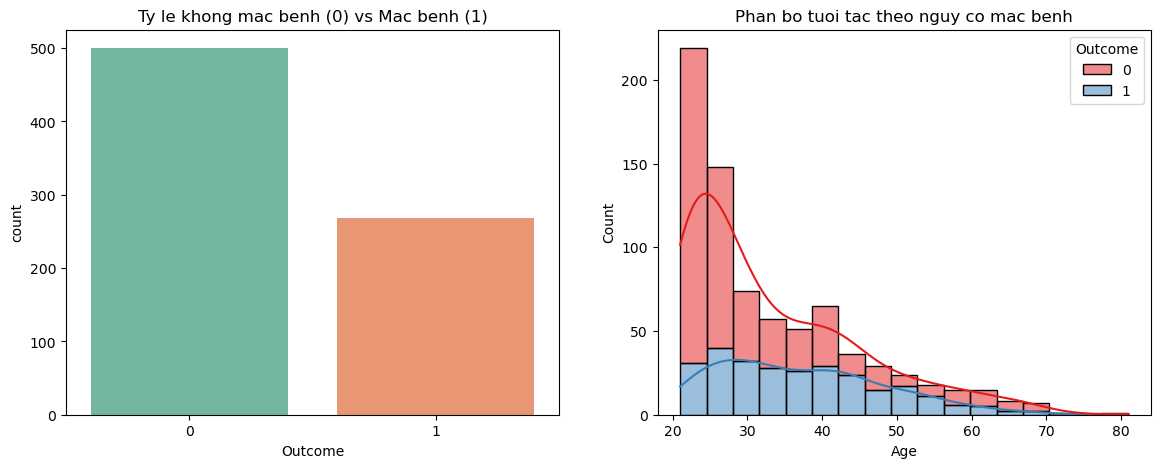

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Câu 1: Tỷ lệ người mắc bệnh
sns.countplot(ax=axes[0], x='Outcome', data=df, palette='Set2')
axes[0].set_title('Ty le khong mac benh (0) vs Mac benh (1)')

# Câu 2: Phân bố độ tuổi nguy cơ cao
sns.histplot(ax=axes[1], data=df, x='Age', hue='Outcome', kde=True, multiple='stack', palette='Set1')
axes[1].set_title('Phan bo tuoi tac theo nguy co mac benh')

plt.show()

C:\Users\mitcl\AppData\Local\Temp\ipykernel_31696\2427416421.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='Outcome', y='Glucose', data=df, palette='Set2')
C:\Users\mitcl\AppData\Local\Temp\ipykernel_31696\2427416421.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='Outcome', y='BMI', data=df, palette='Set2')
C:\Users\mitcl\AppData\Local\Temp\ipykernel_31696\2427416421.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[2], x='Outcome', y='DiabetesPedigreeFunction', data=df, palette='Set2')


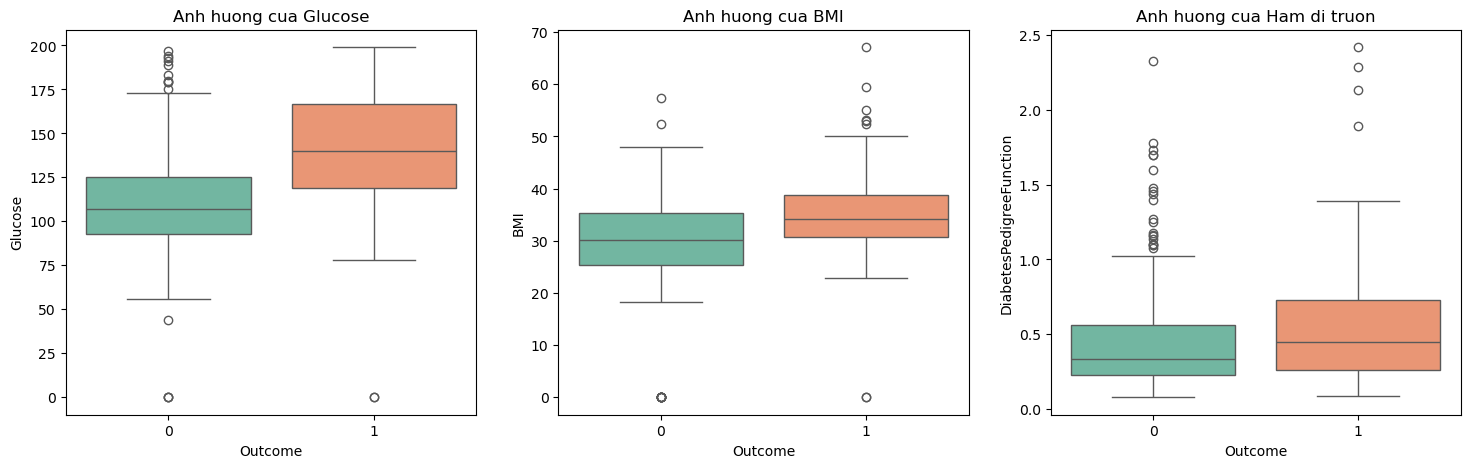

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Câu 3: Khảo sát Glucose
sns.boxplot(ax=axes[0], x='Outcome', y='Glucose', data=df, palette='Set2')
axes[0].set_title('Anh huong cua Glucose')

# Câu 4: Khảo sát BMI
sns.boxplot(ax=axes[1], x='Outcome', y='BMI', data=df, palette='Set2')
axes[1].set_title('Anh huong cua BMI')

# Câu 5: Khảo sát Yếu tố di truyền
sns.boxplot(ax=axes[2], x='Outcome', y='DiabetesPedigreeFunction', data=df, palette='Set2')
axes[2].set_title('Anh huong cua Ham di truon')

plt.show()

In [12]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Thay thế các giá trị 0 vô lý bằng NaN để dễ xử lý
cols_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_fix] = df[cols_fix].replace(0, np.nan)

# 2. Điền các giá trị thiếu (NaN) bằng giá trị trung bình (mean) của cột đó
df.fillna(df.mean(), inplace=True)

# 3. Chia dữ liệu thành Đặc trưng (X) và Nhãn mục tiêu (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 4. Chia tập dữ liệu thành 80% để học (Train) và 20% để kiểm tra (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Chuẩn hóa dữ liệu (đưa các số liệu về cùng một quy chuẩn để máy học nhanh hơn)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Đã tiền xử lý xong! Dữ liệu đã sẵn sàng để huấn luyện.")

Đã tiền xử lý xong! Dữ liệu đã sẵn sàng để huấn luyện.


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Khởi tạo mô hình
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Bắt đầu cho Máy học (Training)
model.fit(X_train, y_train)

# 3. Dùng mô hình đã học để dự đoán trên tập kiểm tra (Test)
y_pred = model.predict(X_test)

# 4. Đánh giá độ chính xác
accuracy = accuracy_score(y_test, y_pred)
print(f"Độ chính xác của mô hình: {accuracy * 100:.2f}%")
print("\nBáo cáo chi tiết:")
print(classification_report(y_test, y_pred))

Độ chính xác của mô hình: 75.32%

Báo cáo chi tiết:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        99
           1       0.65      0.65      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



In [14]:
import joblib
import os

# Tạo thư mục models nếu chưa có (lùi 1 cấp ra ngoài thư mục gốc)
os.makedirs('../models', exist_ok=True)

# Lưu mô hình Random Forest và bộ chuẩn hóa StandardScaler lại
joblib.dump(model, '../models/diabetes_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

print("Đã đóng gói và lưu mô hình thành công vào thư mục 'models'!")

Đã đóng gói và lưu mô hình thành công vào thư mục 'models'!
